In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
huu10diemtoan_athletepose3d_path = kagglehub.dataset_download('huu10diemtoan/athletepose3d')

print('Data source import complete.')


# Import libraries

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import os
import glob
import re
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Graph Definition
- Human skeleton is represented as a graph (joints as vertices, bones as edges).

In [ ]:
def normalize_digraph(A):
    Dl = np.sum(A, 0)
    num_node = A.shape[0]
    Dn = np.zeros((num_node, num_node))
    for i in range(num_node):
        if Dl[i] > 0:
            Dn[i, i] = Dl[i]**(-1)
    return np.dot(A, Dn)

def get_spatial_graph(num_node, self_link, inward, outward):
    I = np.eye(num_node)
    In = np.zeros((num_node, num_node))
    Out = np.zeros((num_node, num_node))
    for i, j in inward:
        In[j, i] = 1
    for i, j in outward:
        Out[j, i] = 1
    A = np.stack((I, normalize_digraph(In), normalize_digraph(Out)))
    return A

# COCO 17 joints format
class GraphCOCO:
    def __init__(self, labeling_mode='spatial'):
        self.num_node = 17
        self.self_link = [(i, i) for i in range(self.num_node)]
        # COCO inward edges (towards center)
        self.inward = [(15, 13), (13, 11), (16, 14), (14, 12), (11, 5), (12, 6),
                       (9, 7), (7, 5), (10, 8), (8, 6), (5, 0), (6, 0),
                       (1, 0), (2, 0), (3, 1), (4, 2)]
        self.outward = [(j, i) for (i, j) in self.inward]
        self.neighbor = self.inward + self.outward
        self.A = self.get_adjacency_matrix(labeling_mode)

    def get_adjacency_matrix(self, labeling_mode=None):
        if labeling_mode == 'spatial':
            return get_spatial_graph(self.num_node, self.self_link, self.inward, self.outward)
        else:
            raise ValueError()

# 2. CTR-GC Modules

**Spatial Modelling:**
- Use 3 CTR-GCs blocks in parallel to extract correlations between human joints and sum up their results as output
- Extract features of graph with input feature, adopt to skeleton graph sequences by pool along temporal dimension to aggregate temporal features, then conducts pair wise subtraction and activation.

**Temporal Convolutions (TCN Blocks):**
- Contain four branches, each contain a 1x1 convolution to reduce channel dimension.
- First three bracnhes contains two temporal convolution with dilation=1, 2 and MaxPool respectively.
- Results are concatenated to obtain the output.

**Entire Network:**
- Number of channels for ten blocks are $64-644-64-128-128-128-256-256-256$, follow by a global average pooling and softmax classifier to predict action labels.
- Temporal dimension is halved at the $5^{th}$ and $8^{th}$ blocks by strided temporal convolution.

In [ ]:
# helper function
def conv_init(conv):
    if conv.weight is not None:
        nn.init.kaiming_normal_(conv.weight, mode='fan_out')
    if conv.bias is not None:
        nn.init.constant_(conv.bias, 0)

def bn_init(bn, scale):
    nn.init.constant_(bn.weight, scale)
    nn.init.constant_(bn.bias, 0)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        if hasattr(m, 'weight'):
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
        if hasattr(m, 'bias') and m.bias is not None and isinstance(m.bias, torch.Tensor):
            nn.init.constant_(m.bias, 0)
    elif classname.find('BatchNorm') != -1:
        if hasattr(m, 'weight') and m.weight is not None:
            m.weight.data.normal_(1.0, 0.02)
        if hasattr(m, 'bias') and m.bias is not None:
            m.bias.data.fill_(0)

class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1):
        super(TemporalConv, self).__init__()
        pad = (kernel_size + (kernel_size-1) * (dilation-1) - 1) // 2
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(kernel_size, 1), padding=(pad, 0), stride=(stride, 1), dilation=(dilation, 1))
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return self.bn(self.conv(x))

class MultiScale_TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dilations=[1,2,3,4], residual=True, residual_kernel_size=1):
        super().__init__()
        assert out_channels % (len(dilations) + 2) == 0, '# out channels should be multiples of # branches'
        self.num_branches = len(dilations) + 2
        branch_channels = out_channels // self.num_branches
        if type(kernel_size) == list:
            assert len(kernel_size) == len(dilations)
        else:
            kernel_size = [kernel_size]*len(dilations)

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(branch_channels),
                nn.ReLU(inplace=True),
                TemporalConv(branch_channels, branch_channels, kernel_size=ks, stride=stride, dilation=dilation),
            ) for ks, dilation in zip(kernel_size, dilations)
        ])

        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(3,1), stride=(stride,1), padding=(1,0)),
            nn.BatchNorm2d(branch_channels)
        ))

        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0, stride=(stride,1)),
            nn.BatchNorm2d(branch_channels)
        ))

        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = TemporalConv(in_channels, out_channels, kernel_size=residual_kernel_size, stride=stride)
        self.apply(weights_init)

    def forward(self, x):
        res = self.residual(x)
        branch_outs = [tempconv(x) for tempconv in self.branches]
        out = torch.cat(branch_outs, dim=1)
        out += res
        return out

class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels, rel_reduction=8, mid_reduction=1):
        super(CTRGC, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        if in_channels == 3 or in_channels == 9 or in_channels == 2:
            self.rel_channels = 8
            self.mid_channels = 16
        else:
            self.rel_channels = in_channels // rel_reduction
            self.mid_channels = in_channels // mid_reduction
        self.conv1 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(self.in_channels, self.out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, self.out_channels, kernel_size=1)
        self.tanh = nn.Tanh()
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                conv_init(m)
            elif isinstance(m, nn.BatchNorm2d):
                bn_init(m, 1)

    def forward(self, x, A=None, alpha=1):
        x1, x2, x3 = self.conv1(x).mean(-2), self.conv2(x).mean(-2), self.conv3(x)
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1) * alpha + (A.unsqueeze(0).unsqueeze(0) if A is not None else 0)
        x1 = torch.einsum('ncuv,nctv->nctu', x1, x3)
        return x1

class unit_tcn(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, stride=1):
        super(unit_tcn, self).__init__()
        pad = int((kernel_size - 1) / 2)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(kernel_size, 1), padding=(pad, 0), stride=(stride, 1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        conv_init(self.conv)
        bn_init(self.bn, 1)

    def forward(self, x):
        return self.bn(self.conv(x))

class unit_gcn(nn.Module):
    def __init__(self, in_channels, out_channels, A, coff_embedding=4, adaptive=True, residual=True):
        super(unit_gcn, self).__init__()
        self.num_subset = A.shape[0]
        self.adaptive = adaptive
        self.convs = nn.ModuleList([CTRGC(in_channels, out_channels) for i in range(self.num_subset)])

        if residual:
            if in_channels != out_channels:
                self.down = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
            else:
                self.down = lambda x: x
        else:
            self.down = lambda x: 0

        if self.adaptive:
            self.PA = nn.Parameter(torch.from_numpy(A.astype(np.float32)))
        else:
            self.A = Variable(torch.from_numpy(A.astype(np.float32)), requires_grad=False)

        self.alpha = nn.Parameter(torch.zeros(1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                conv_init(m)
            elif isinstance(m, nn.BatchNorm2d):
                bn_init(m, 1)
        bn_init(self.bn, 1e-6)

    def forward(self, x):
        y = None
        A = self.PA if self.adaptive else self.A.cuda(x.get_device())
        for i in range(self.num_subset):
            z = self.convs[i](x, A[i], self.alpha)
            y = z + y if y is not None else z
        y = self.bn(y)
        y += self.down(x)
        return self.relu(y)

class TCN_GCN_unit(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, adaptive=True, kernel_size=5, dilations=[1,2]):
        super(TCN_GCN_unit, self).__init__()
        self.gcn1 = unit_gcn(in_channels, out_channels, A, adaptive=adaptive)
        self.tcn1 = MultiScale_TemporalConv(out_channels, out_channels, kernel_size=kernel_size, stride=stride, dilations=dilations, residual=False)
        self.relu = nn.ReLU(inplace=True)
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = unit_tcn(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        return self.relu(self.tcn1(self.gcn1(x)) + self.residual(x))

class CTRGCN_Model(nn.Module):
    def __init__(self, num_class, num_point=17, num_person=1, graph_class=GraphCOCO, in_channels=3, drop_out=0, adaptive=True):
        super(CTRGCN_Model, self).__init__()
        self.graph = graph_class()
        A = self.graph.A

        self.num_class = num_class
        self.num_point = num_point
        self.data_bn = nn.BatchNorm1d(num_person * in_channels * num_point)

        base_channel = 64
        self.l1 = TCN_GCN_unit(in_channels, base_channel, A, residual=False, adaptive=adaptive)
        self.l2 = TCN_GCN_unit(base_channel, base_channel, A, adaptive=adaptive)
        self.l3 = TCN_GCN_unit(base_channel, base_channel, A, adaptive=adaptive)
        self.l4 = TCN_GCN_unit(base_channel, base_channel, A, adaptive=adaptive)
        self.l5 = TCN_GCN_unit(base_channel, base_channel*2, A, stride=2, adaptive=adaptive)
        self.l6 = TCN_GCN_unit(base_channel*2, base_channel*2, A, adaptive=adaptive)
        self.l7 = TCN_GCN_unit(base_channel*2, base_channel*2, A, adaptive=adaptive)
        self.l8 = TCN_GCN_unit(base_channel*2, base_channel*4, A, stride=2, adaptive=adaptive)
        self.l9 = TCN_GCN_unit(base_channel*4, base_channel*4, A, adaptive=adaptive)
        self.l10 = TCN_GCN_unit(base_channel*4, base_channel*4, A, adaptive=adaptive)

        self.fc = nn.Linear(base_channel*4, num_class)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2. / num_class))
        bn_init(self.data_bn, 1)
        self.drop_out = nn.Dropout(drop_out) if drop_out else lambda x: x

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M * V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)

        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.l5(x)
        x = self.l6(x)
        x = self.l7(x)
        x = self.l8(x)
        x = self.l9(x)
        x = self.l10(x)

        c_new = x.size(1)
        x = x.view(N, M, c_new, -1)
        x = x.mean(3).mean(1)
        x = self.drop_out(x)
        return self.fc(x)

# 3. Data Pre-processing and Augmentation

In [ ]:
def inspect_dataset_files(dataset_root, skeleton_format='coco', num_files_to_check=1):
    """
    Finds and inspects random .npy files in the dataset to understand their structure.
    """
    print(f"--- Inspecting AthletePose3D ({skeleton_format.upper()} format) ---")

    # Search for all files matching the format in the train directory
    search_pattern = os.path.join(dataset_root, 'train', '*', f'*_{skeleton_format}.npy')
    all_files = glob.glob(search_pattern)

    if not all_files:
        print(f"No files found matching pattern: {search_pattern}")
        return

    print(f"Found {len(all_files)} total files in the training set.\n")

    # Pick a few random files to inspect
    np.random.seed(42) # For reproducibility
    sample_files = np.random.choice(all_files, min(num_files_to_check, len(all_files)), replace=False)

    for file_path in sample_files:
        filename = os.path.basename(file_path)
        print(f"File: {filename}")

        try:
            # Load the numpy array
            data = np.load(file_path)

            # Extract basic properties
            shape = data.shape
            dtype = data.dtype
            has_nans = np.isnan(data).any()
            nan_count = np.isnan(data).sum()
            min_val = np.nanmin(data) if not has_nans or nan_count < data.size else "N/A"
            max_val = np.nanmax(data) if not has_nans or nan_count < data.size else "N/A"

            print(f"Shape: {shape}")
            print(f"Frames (T): {shape[0]}")
            print(f"Keypoints/Joints (V): {shape[1]}")
            print(f"Coordinates (C): {shape[2]}")
            print(f"Value Range: Min = {min_val:.4f}, Max = {max_val:.4f}")
            print(f"Contains NaNs: {has_nans} (Count: {nan_count})")
            print("-" * 50)

        except Exception as e:
            print(f"Error reading file: {e}")

# inspection
DATASET_ROOT = '/kaggle/input/datasets/huu10diemtoan/athletepose3d/AtheletePose3D'

inspect_dataset_files(DATASET_ROOT, skeleton_format='coco', num_files_to_check=3)

--- Inspecting AthletePose3D (COCO format) ---
Found 2856 total files in the training set.

File: Lutz_2_cam_4_coco.npy
Shape: (155, 17, 2)
Frames (T): 155
Keypoints/Joints (V): 17
Coordinates (C): 2
Value Range: Min = 475.8902, Max = 1911.0797
Contains NaNs: True (Count: 1240)
--------------------------------------------------
File: Loop_4_cam_3_coco.npy
Shape: (298, 17, 2)
Frames (T): 298
Keypoints/Joints (V): 17
Coordinates (C): 2
Value Range: Min = 441.1496, Max = 1916.3411
Contains NaNs: True (Count: 2384)
--------------------------------------------------
File: Javelin_2_cam_7_coco.npy
Shape: (250, 17, 2)
Frames (T): 250
Keypoints/Joints (V): 17
Coordinates (C): 2
Value Range: Min = 1.5813, Max = 1326.7199
Contains NaNs: True (Count: 2000)
--------------------------------------------------


--- 1. EDA: Raw Dataset Analysis ---
Total raw files found: 5154


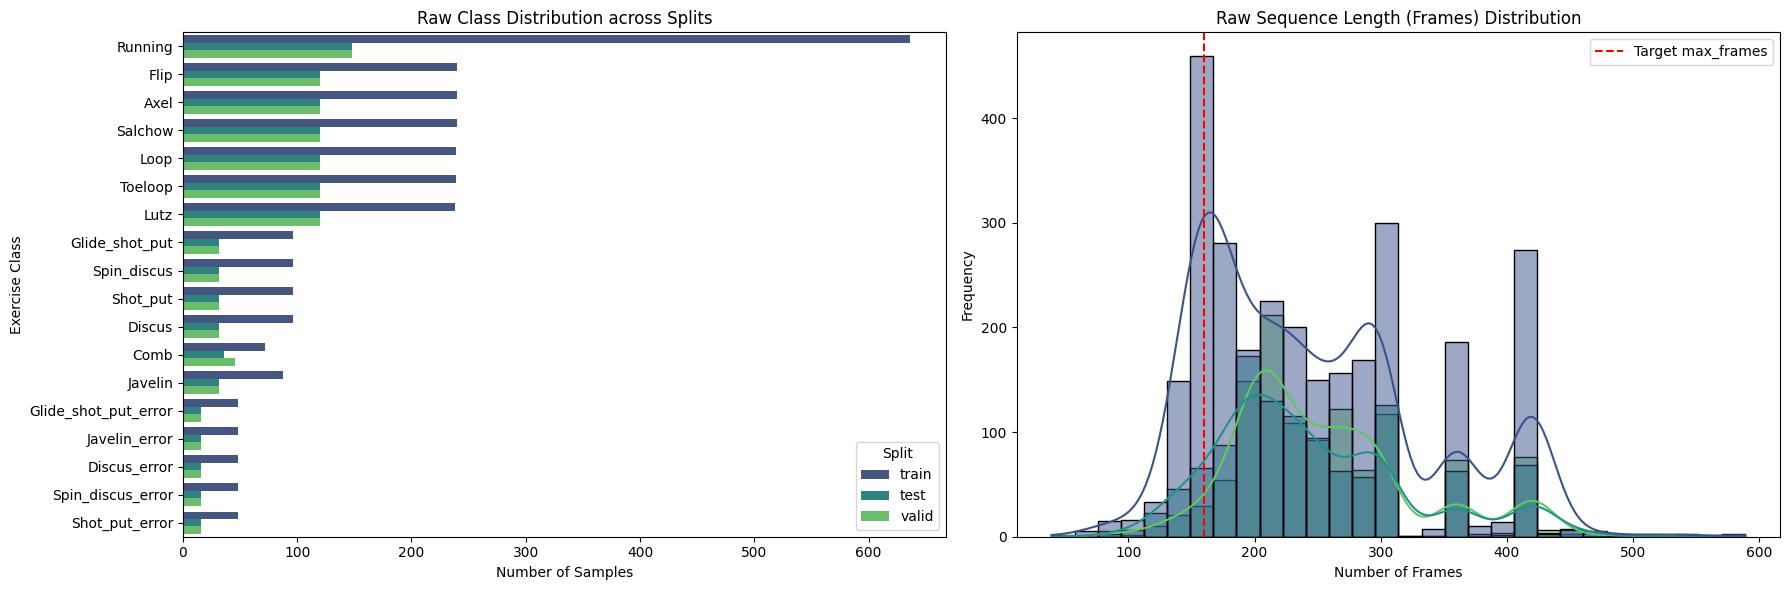

In [ ]:
def eda_raw_dataset(dataset_root, skeleton_format='coco'):
    print("--- 1. EDA: Raw Dataset Analysis ---")

    stats = []
    splits = ['train', 'test', 'valid']

    for split in splits:
        split_dir = os.path.join(dataset_root, split)
        if not os.path.exists(split_dir):
            continue

        files = glob.glob(os.path.join(split_dir, '*', f'*_{skeleton_format}.npy'))

        for f in files:
            basename = os.path.basename(f)
            match = re.match(r"^([a-zA-Z_]+)_\d+_cam_\d+_" + skeleton_format + r"\.npy$", basename)
            if match:
                exercise = match.group(1)

                # Load just to get shape and basic stats
                data = np.load(f)
                frames = data.shape[0]
                has_nan = np.isnan(data).any()

                stats.append({
                    'Split': split,
                    'Class': exercise,
                    'Frames': frames,
                    'Has_NaN': has_nan,
                    'Raw_Max': np.nanmax(data) if not has_nan else np.nanmax(np.nan_to_num(data))
                })

    df = pd.DataFrame(stats)

    if df.empty:
        print("No data found to analyze.")
        return

    print(f"Total raw files found: {len(df)}")

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Class Distribution
    sns.countplot(data=df, y='Class', hue='Split', ax=axes[0], order=df['Class'].value_counts().index, palette='viridis')
    axes[0].set_title('Raw Class Distribution across Splits')
    axes[0].set_xlabel('Number of Samples')
    axes[0].set_ylabel('Exercise Class')

    # 2. Sequence Length Distribution
    sns.histplot(data=df, x='Frames', hue='Split', kde=True, ax=axes[1], palette='viridis', bins=30)
    axes[1].set_title('Raw Sequence Length (Frames) Distribution')
    axes[1].set_xlabel('Number of Frames')
    axes[1].set_ylabel('Frequency')

    # Add a line to show our target max_frames
    axes[1].axvline(x=160, color='red', linestyle='--', label='Target max_frames')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
eda_raw_dataset(DATASET_ROOT, skeleton_format='coco')

In [ ]:
class AthletePose3DDataset(Dataset):
    def __init__(self, split_dirs, skeleton_format='coco', max_frames=160):
        """
        split_dirs: A single path OR a list of paths (e.g., ['/path/to/train', '/path/to/test'])
        skeleton_format: 'coco' or 'h36m' (matches the file suffix)
        max_frames: Fixed temporal length required by the GCN model
        """
        if isinstance(split_dirs, str):
            split_dirs = [split_dirs]

        self.split_dirs = split_dirs
        self.format = skeleton_format
        self.max_frames = max_frames
        self.file_paths = []
        self.labels = []

        all_files = []
        for d in self.split_dirs:
            search_pattern = os.path.join(d, '*', f'*_{self.format}.npy')
            all_files.extend(glob.glob(search_pattern))

        if len(all_files) == 0:
            print(f"Warning: No {self.format} files found in {split_dirs}!")
            return

        self.class_names = set()
        for f in all_files:
            basename = os.path.basename(f)
            match = re.match(r"^([a-zA-Z_]+)_\d+_cam_\d+_" + self.format + r"\.npy$", basename)
            if match:
                exercise_name = match.group(1)
                self.class_names.add(exercise_name)

        self.class_names = sorted(list(self.class_names))
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        for f in all_files:
            basename = os.path.basename(f)
            match = re.match(r"^([a-zA-Z_]+)_\d+_cam_\d+_" + self.format + r"\.npy$", basename)
            if match:
                exercise_name = match.group(1)
                self.file_paths.append(f)
                self.labels.append(self.class_to_idx[exercise_name])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        data = np.load(file_path)
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

        T = data.shape[0]

        # --- TEMPORAL AUGMENTATION & SAMPLING ---
        if T > self.max_frames:
            # Standard evenly spaced frames for validation
            indices = np.linspace(0, T - 1, self.max_frames, dtype=int)
            data = data[indices]

        elif T < self.max_frames:
            pad_len = self.max_frames - T
            # Standard edge padding at the end for validation
            data = np.pad(data, ((0, pad_len), (0, 0), (0, 0)), mode='edge')

        # ---NORMALIZATION ---
        root_joint = data[:, 0:1, :]
        data = data - root_joint

        if np.max(np.abs(data)) > 10:
            data = data / 500.0

        # --- RESHAPE FOR CTR-GCN ---
        data = np.transpose(data, (2, 0, 1))
        data = np.expand_dims(data, axis=-1)

        return torch.tensor(data, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

## Setup Data Loader

In [ ]:
train_dataset = AthletePose3DDataset(os.path.join(DATASET_ROOT, 'train'), skeleton_format='coco')
val_dataset = AthletePose3DDataset(os.path.join(DATASET_ROOT, 'valid'), skeleton_format='coco')

if len(train_dataset) > 0:
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    num_classes = len(train_dataset.class_names)
    print(f"DataLoaders ready! Training sequences: {len(train_dataset)}, Validation sequences: {len(val_dataset)}")
else:
    print("Datasets are not loaded properly. Please run the dataset implementation cell first.")

DataLoaders ready! Training sequences: 2856, Validation sequences: 1154


# 4. Training
- Trained with SGD with momemtum $0.9$, weight decay $0.0005$, epoch is set to $50$, warmup strategy is used in the first $5$ epochs, learning rate $0.1$, decay with factor $0.1$ at epoch $20$ and $40$.
- Batch size is $32$, each sample resize to $256$ frames.

In [ ]:
def init_seed(seed=1):
    torch.cuda.manual_seed_all(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def adjust_learning_rate(optimizer, epoch, base_lr, warm_up_epoch, step, lr_decay_rate):
    """Replicates the custom warmup and step decay from ref repo"""
    if epoch < warm_up_epoch:
        lr = base_lr * (epoch + 1) / warm_up_epoch
    else:
        lr = base_lr * (lr_decay_rate ** np.sum(epoch >= np.array(step)))

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_evaluate(train_loader, val_loader, num_classes):
    init_seed(1)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model = CTRGCN_Model(num_class=num_classes, num_point=17, num_person=1,
                         graph_class=GraphCOCO, in_channels=2, drop_out=0.5).to(device)

    print(f'# Model Parameters: {count_parameters(model):,}')

    criterion = nn.CrossEntropyLoss().to(device)

    base_lr = 0.05
    warm_up_epoch = 5
    step = [20, 40]
    lr_decay_rate = 0.1
    epochs = 50

    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9, weight_decay=0.0005, nesterov=True)

    best_val_acc = 0.0
    best_epoch = 0
    patience = 20
    epochs_no_improve = 0

    for epoch in range(epochs):
        start_time = time.time()

        # --- Training Phase ---
        model.train()
        current_lr = adjust_learning_rate(optimizer, epoch, base_lr, warm_up_epoch, step, lr_decay_rate)

        train_loss = 0.0
        correct = 0
        total = 0

        timer = dict(dataloader=0.0, model=0.0)
        cur_time = time.time()

        for data, labels in train_loader:
            # Profile dataloader time
            timer['dataloader'] += time.time() - cur_time
            cur_time = time.time()

            data, labels = data.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Profile model compute time
            timer['model'] += time.time() - cur_time
            cur_time = time.time()

            train_loss += loss.item() * data.size(0)
            _, predicted = output.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        avg_train_loss = train_loss / total

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, labels in val_loader:
                data, labels = data.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
                output = model(data)
                loss = criterion(output, labels)

                val_loss += loss.item() * data.size(0)
                _, predicted = output.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        avg_val_loss = val_loss / val_total
        epoch_time = time.time() - start_time

        # Calculate bottleneck percentages
        total_compute_time = sum(timer.values()) + 1e-8
        prop_data = int(round(timer['dataloader'] * 100 / total_compute_time))
        prop_model = int(round(timer['model'] * 100 / total_compute_time))

        # Clean Single-Line Logging
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Time: {epoch_time:.1f}s | LR: {current_lr:.4f} | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # --- Checkpointing & Early Stopping ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best.pth')
            print(f"  -> New best validation accuracy! Saved to 'best.pth'")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs!")
            break

    print(f"\nTraining Complete. Best Validation Accuracy: {best_val_acc:.2f}% achieved at Epoch {best_epoch}.")

# Execute Training
train_and_evaluate(train_loader, val_loader, num_classes)

Using device: cuda
# Model Parameters: 1,425,262
Epoch [001/50] | Time: 41.9s | LR: 0.0100 | Train Loss: 7.3963, Train Acc: 18.94% | Val Loss: 2.2192, Val Acc: 26.52%
  -> New best validation accuracy! Saved to 'best.pth'
Epoch [002/50] | Time: 41.8s | LR: 0.0200 | Train Loss: 3.6628, Train Acc: 29.10% | Val Loss: 1.8830, Val Acc: 27.47%
  -> New best validation accuracy! Saved to 'best.pth'
Epoch [003/50] | Time: 41.8s | LR: 0.0300 | Train Loss: 2.3903, Train Acc: 34.24% | Val Loss: 2.0170, Val Acc: 22.88%
Epoch [004/50] | Time: 41.9s | LR: 0.0400 | Train Loss: 1.8959, Train Acc: 36.76% | Val Loss: 1.7031, Val Acc: 31.72%
  -> New best validation accuracy! Saved to 'best.pth'
Epoch [005/50] | Time: 41.9s | LR: 0.0500 | Train Loss: 1.6160, Train Acc: 40.90% | Val Loss: 1.7581, Val Acc: 29.55%
Epoch [006/50] | Time: 41.8s | LR: 0.0500 | Train Loss: 1.4786, Train Acc: 42.33% | Val Loss: 1.5534, Val Acc: 39.25%
  -> New best validation accuracy! Saved to 'best.pth'
Epoch [007/50] | Time: 

Evaluating on device: cuda
Running inference over the validation set...


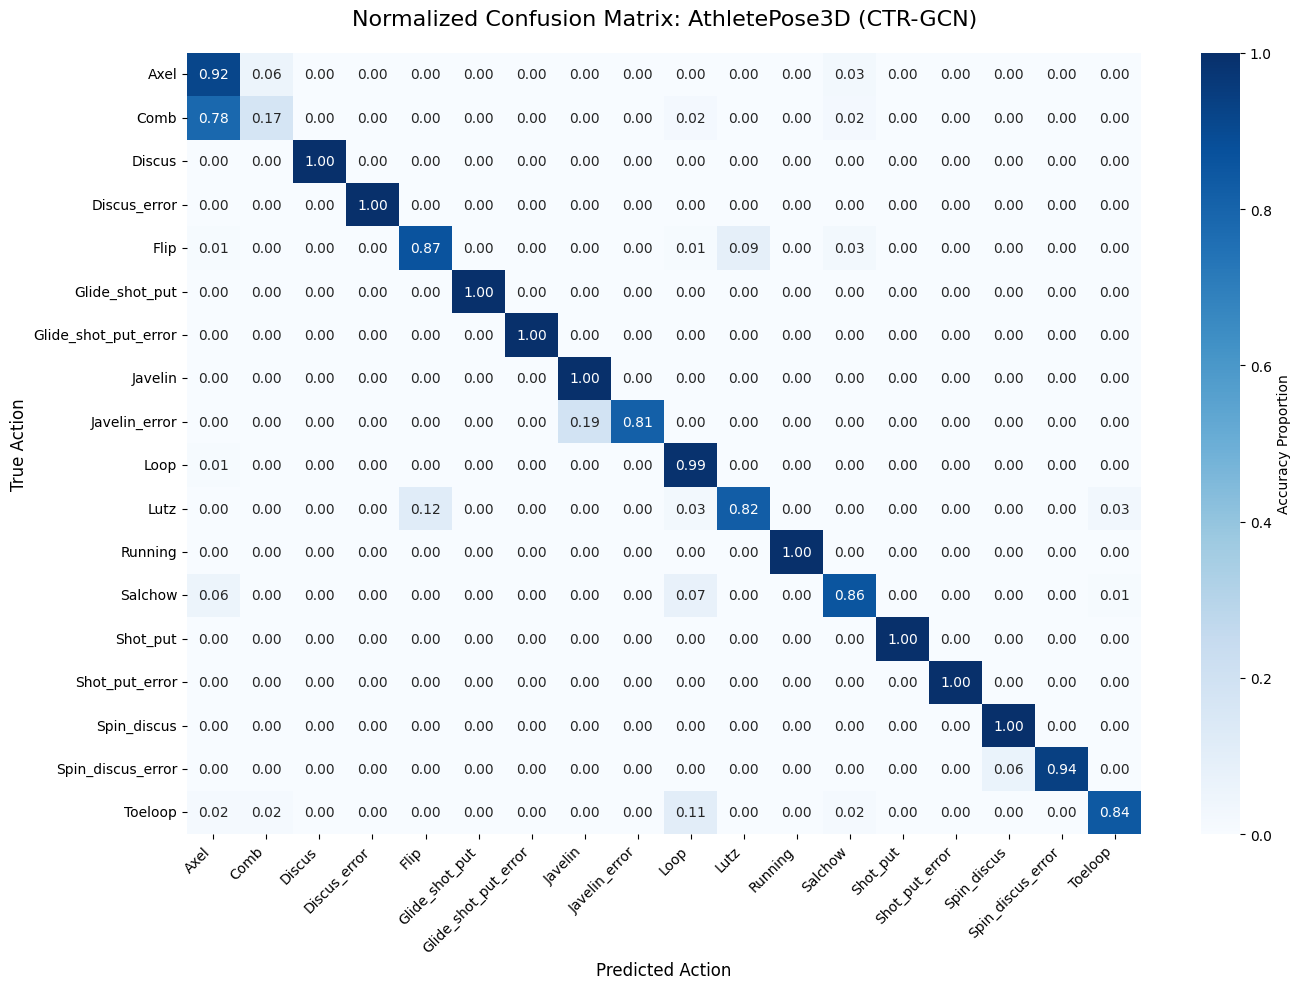


--- Detailed Classification Report ---
                      precision    recall  f1-score   support

                Axel       0.70      0.92      0.79       120
                Comb       0.47      0.17      0.25        46
              Discus       1.00      1.00      1.00        32
        Discus_error       1.00      1.00      1.00        16
                Flip       0.88      0.87      0.87       120
      Glide_shot_put       1.00      1.00      1.00        32
Glide_shot_put_error       1.00      1.00      1.00        16
             Javelin       0.91      1.00      0.96        32
       Javelin_error       1.00      0.81      0.90        16
                Loop       0.82      0.99      0.89       120
                Lutz       0.90      0.82      0.86       120
             Running       1.00      1.00      1.00       148
             Salchow       0.92      0.86      0.89       120
            Shot_put       1.00      1.00      1.00        32
      Shot_put_error       1.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_and_plot_confusion_matrix(model_weights_path, val_loader, class_names):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Evaluating on device: {device}")

    # 1. Initialize model and load best weights
    model = CTRGCN_Model(num_class=len(class_names), num_point=17, num_person=1,
                         graph_class=GraphCOCO, in_channels=2).to(device)

    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval() # Crucial: turns off dropout during inference

    all_preds = []
    all_labels = []

    print("Running inference over the validation set...")

    # 2. Gather all predictions and true labels
    with torch.no_grad():
        for data, labels in val_loader:
            data = data.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)

            outputs = model(data)
            _, predicted = torch.max(outputs, 1)

            # Move data back to CPU for Scikit-Learn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 3. Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalize the confusion matrix to show percentages instead of raw counts
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 4. Plotting
    plt.figure(figsize=(14, 10)) # Large figure to fit 18 classes cleanly
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Accuracy Proportion'})

    plt.title('Normalized Confusion Matrix: AthletePose3D (CTR-GCN)', fontsize=16, pad=20)
    plt.ylabel('True Action', fontsize=12)
    plt.xlabel('Predicted Action', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 5. Print a detailed text report (Precision, Recall, F1-Score per class)
    print("\n--- Detailed Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))


# ==========================================
# Execute the Evaluation
# ==========================================

# Ensure variables from previous cells are loaded
if 'val_loader' in locals() and 'train_dataset' in locals():
    weights_file = 'best.pth'
    my_classes = train_dataset.class_names

    evaluate_and_plot_confusion_matrix(weights_file, val_loader, my_classes)
else:
    print("Please ensure your validation DataLoader (val_loader) is loaded in memory first.")